# Customer Segmentation using Hierarchical Clustering

This project segments customers based on purchasing behavior using unsupervised learning.

In [1]:
# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

%matplotlib inline

# Display formatting
from IPython.core.display import HTML
HTML("""
<style>
.dataframe table, .dataframe th, .dataframe td { font-size: 14px; }
div.output_scroll { overflow-x: auto; }
</style>
""")

import os
os.environ["OMP_NUM_THREADS"] = "4"


### Loading the Dataset


In [2]:
mall = pd.read_csv("mall_customers.csv")

mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [4]:
mall.isna().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

We inspect data structure and missing values before processing.

## Data Cleaning

In [5]:
mall.columns = [
    "customer_id",
    "gender",
    "age",
    "annual_income",
    "spending_score"
]

In [6]:
mall = mall.drop("customer_id", axis=1)
mall.head()

,gender,age,annual_income,spending_score
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


In [7]:
mall["gender"] = mall["gender"].fillna(mall["gender"].mode()[0])

mall["age"] = mall["age"].fillna(mall["age"].median())

mall["annual_income"] = mall["annual_income"].fillna(mall["annual_income"].median())

mall["spending_score"] = mall["spending_score"].fillna(mall["spending_score"].median())

## Exploratory Data Analysis

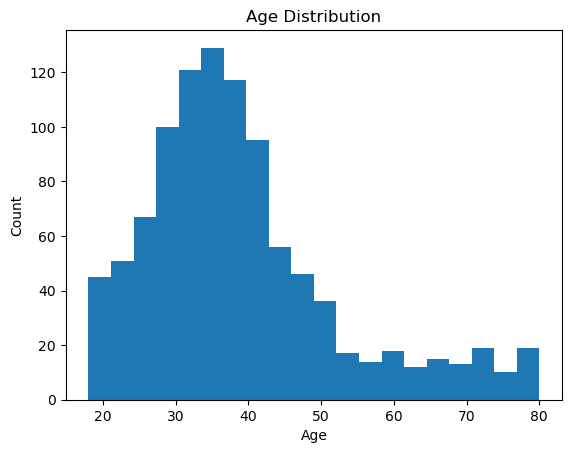

In [9]:
plt.hist(mall["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

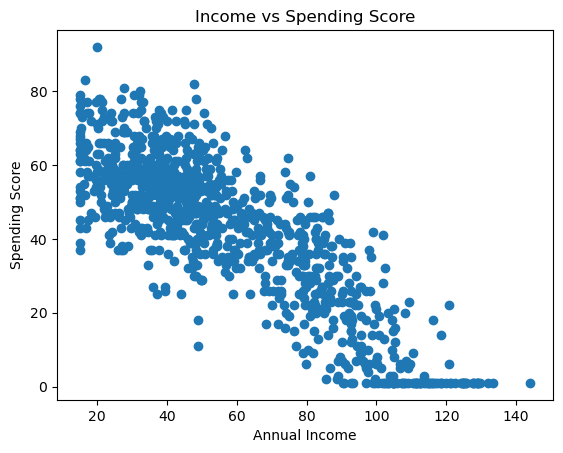

In [10]:
plt.scatter(mall["annual_income"], mall["spending_score"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

## Feature Selection

In [11]:
X = mall[["annual_income", "spending_score"]]
X.head()

,annual_income,spending_score
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


We select only income and spending score for clustering.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.09745644,  0.76510194],
       [-0.3051838 , -0.28311966],
       [ 0.46858571, -0.83218813],
       [ 0.83971497, -0.63252687],
       [-0.52576062,  0.76510194]])

Standardization is applied because Hierarchical Clustering is distance-based.

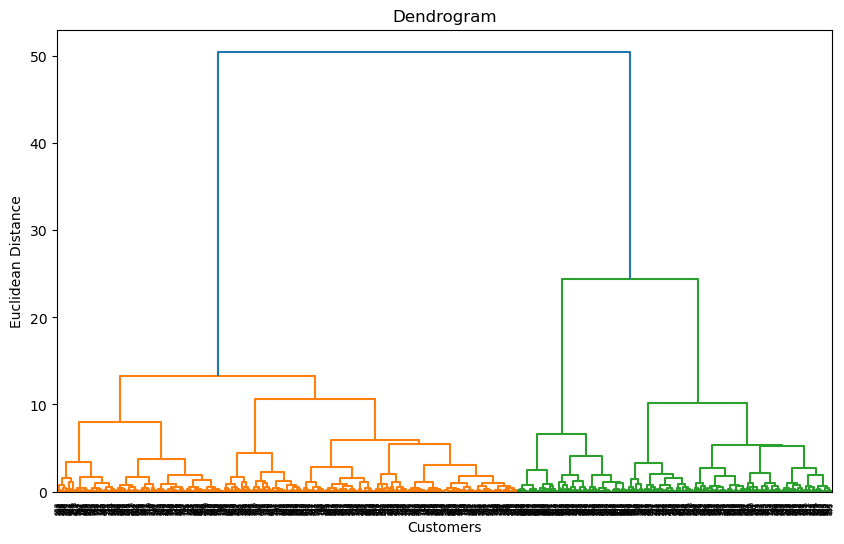

In [14]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [23]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

y_hc

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 2, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 2, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,

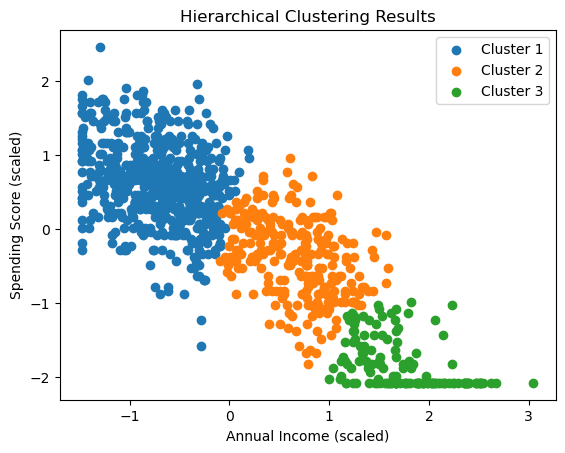

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[y_hc == 0, 0], X_scaled[y_hc == 0, 1], label="Cluster 1")
plt.scatter(X_scaled[y_hc == 1, 0], X_scaled[y_hc == 1, 1], label="Cluster 2")
plt.scatter(X_scaled[y_hc == 2, 0], X_scaled[y_hc == 2, 1], label="Cluster 3")

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Hierarchical Clustering Results")
plt.legend()
plt.show()

##  Insights

- Customers were segmented into 3 distinct groups
- Income and spending score are strongly related to customer behavior
- Hierarchical clustering provided clear segmentation without needing predefined initialization

## Conclusion

Hierarchical Clustering is a powerful unsupervised learning technique for discovering natural groupings in data.

It helped reveal meaningful customer segments that can support business decisions such as marketing strategies and targeting.